# Agglomerative (Hierarchical) Clustering

## Table of Contents

### 1. What is Agglomerative Clustering?

### 2. Agglomerative Clustering in Scikit-Learn

### 3. Evaluation of Clustering

### 4. Important Considerations for Agglomerative Clustering

## 1. What is Agglomerative Clustering?

A hierarchical clustering method that builds a tree (dendrogram) of clusters.

“Agglomerative” means bottom-up:

- Start with each point as its own cluster

- Iteratively merge the two closest clusters

- Repeat until all points are merged into one cluster or a desired number of clusters is reached

Result: a dendrogram (tree diagram showing cluster merges)

Goal: Understand **hierarchical relationships** between data points.

**Unlike K-Means, it does not require random initialization, so results are deterministic given the same parameters**


## 2. Agglomerative Clustering in Scikit-Learn

The name of the class for Agglomerative Clustering in Scikit-Learn
  **sklearn.cluster.AgglomerativeClustering**


## **AgglomerativeClustering Parameters Explained (scikit-learn)**

### **Most Important Parameters**

### `1. n_clusters`
-  The number of clusters to form. Determines how many groups the algorithm will merge the points into.  
- default=2
- If you also set `distance_threshold`, this parameter is ignored because merging is stopped based on distance rather than cluster count.  

### `2.metric`

Distance metric used to calculate similarity between points. Determines which points are “close” to each other.

**Common Options:**  
  - `euclidean` (default) → straight-line distance; most common for numeric features.  
  - `manhattan` → sum of absolute differences; robust to outliers.  
  - `cosine` → measures angle between vectors; useful for text embeddings   

### `3. linkage`

Determines how the distance between **clusters** is computed during merging  

**Options**  

  - `ward` (default) → merges clusters that **minimize the variance** of combined cluster; produces compact, round clusters. Only works with Euclidean distance

  - `complete` → distance = **maximum distance** between any two points across clusters. Produces **tight, well-separated clusters**

  - `average` → distance = **average of all pairwise distances** between points in the two clusters. Balanced behavior between single and complete linkage

Different linkages affect **cluster shape, size and sensitivity to noise**  




**Important rules and constraints:**
- If `linkage="ward"`, **only `"euclidean"` is allowed**  
  (because Ward’s method relies on variance minimization).

Choice of metric affects which points are considered “close” and thus which clusters are merged first  


### **Occasionally Used Parameters**

### `distance_threshold`

Stops merging clusters when the distance between clusters exceeds this threshold.

**Options:** float (default=None)  

- Useful when you want a **hierarchy** and do not know the number of clusters in advance

- Example: `distance_threshold=5` → any clusters separated by more than 5 units will **not merge**, creating more clusters automatically

- If set, `n_clusters` is ignored  


### `compute_full_tree`

Determines whether the full clustering tree is computed. Needed for dendrogram plotting.  

**Options**  (default=auto)
  - `auto` → computes full tree only when needed (e.g., small datasets or dendrogram)
  - `True` → always compute the full tree; useful for plotting dendrograms  
  - `False` → skips computing full tree to save memory and computation for large datasets

### Apply Agglomerative Clustering to a simple Dataset

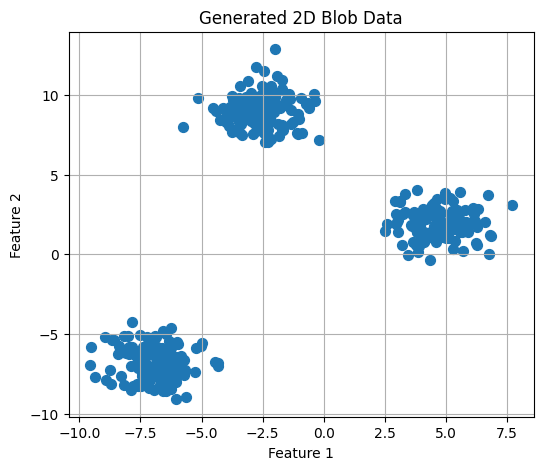

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import pandas as pd
from sklearn.metrics import silhouette_score

# Generate 400 points in 2D, 3 clusters
X, y = make_blobs(n_samples=400, n_features=2, centers=3, random_state=42)

# Plot the raw data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Generated 2D Blob Data")
plt.grid(True)
plt.show()

Silhouette Score: 0.8458787585795497


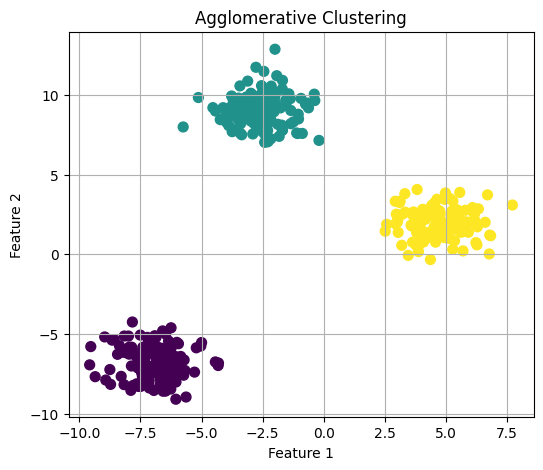

In [ ]:
# Create the model
agg = AgglomerativeClustering(
    n_clusters=3,       # we know 3 clusters exist
    metric='euclidean',  # distance metric
    linkage='ward'          # linkage method
)

# Fit and predict cluster labels
labels = agg.fit_predict(X)
score = silhouette_score(X, labels)
print("Silhouette Score:", score)
# Plot clustered data
plt.figure(figsize=(6,5))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis', s=50)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Agglomerative Clustering")
plt.grid(True)
plt.show()

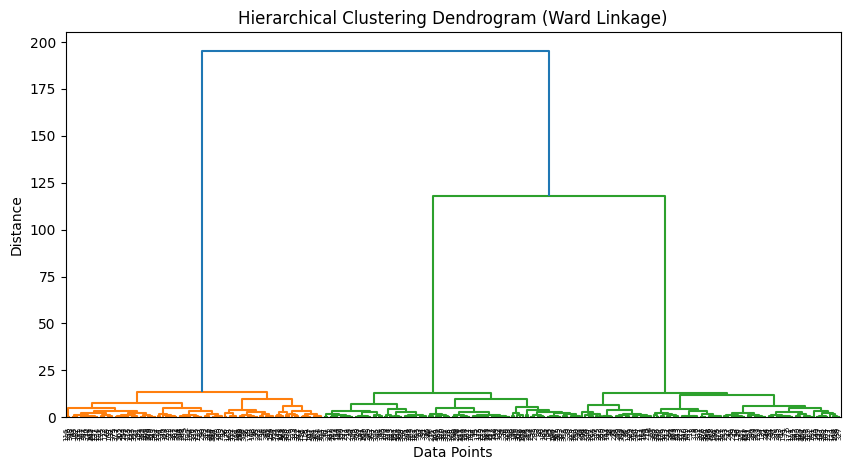

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

Z = linkage(X, method='ward', metric='euclidean')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title("Hierarchical Clustering Dendrogram (Ward Linkage)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

#### How to Interpret the Dendrogram

- Each leaf → one data point

- Each merge → two clusters being combined

- The height of a merge → distance between clusters

#### Choosing the Number of Clusters

- Draw a horizontal line across the dendrogram

- Count how many vertical branches it cuts

### Rule of thumb:

Choose the cut where there is a large vertical gap
(big jump in distance before clusters merge)

## Important Considerations for Agglomerative Clustering

### When to Use Agglomerative Clustering

**- Does not require specifying K upfront:**  
Hierarchical clustering can build a full hierarchy of clusters and allows you to decide the number of clusters later by cutting the dendrogram at a chosen level.

**- Works well with small to medium datasets:**  
Because it computes distances between many pairs of points, it is more suitable when the dataset is not extremely large.

**- Useful for understanding data structure:**  
The dendrogram provides a visual explanation of how data points are grouped, making it useful for exploratory analysis.

**- Flexible cluster shapes (linkage):**  
Different linkage methods allow the algorithm to capture different types of cluster structures


### Limitations of Agglomerative Clustering

**- Computationally expensive:**  
Agglomerative clustering has higher time and memory complexity, making it impractical for very large datasets

**- Sensitive to noise and outliers:**  
Outliers can form their own clusters or distort the merging process

**- Early decisions cannot be undone:**  
Once two clusters are merged, the algorithm cannot reconsider that decision later, which may lead to suboptimal clusters

**- Results depend heavily on linkage choice:**  
Different linkage methods can produce very different clusterings, so parameter selection is critical

## Task 2A: Agglomerative Clustering

In this task, you will apply **Agglomerative Clustering** to `CC GENERAL` dataset and follow **the same methodology** used in the previous clustering lab

## **1. Exploratory Data Analysis (EDA)**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
df = pd.read_csv('CC GENERAL.csv')

print('='*60)
print('DATASET LOADED')
print('='*60)
print(f'Shape: {df.shape[0]:,} customers × {df.shape[1]} features')
print(f'\nColumns:\n{list(df.columns)}')
print('\n' + '='*60)

df.head()

DATASET LOADED
Shape: 8,950 customers × 18 features

Columns:
['CUST_ID', 'BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']



,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
print('Dataset Info:')
print('='*60)
df.info()

print('\n' + '='*60)
print('Statistical Summary:')
print('='*60)
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [ ]:
print('Missing Values Check:')
print('='*60)
missing = df.isnull().sum()
if missing.sum() == 0:
    print('No missing values found!')
else:
    print('Missing values by column:')
    print(missing[missing > 0])
    print(f'\nTotal missing: {missing.sum()}')
print('='*60)

Missing Values Check:
Missing values by column:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Total missing: 314


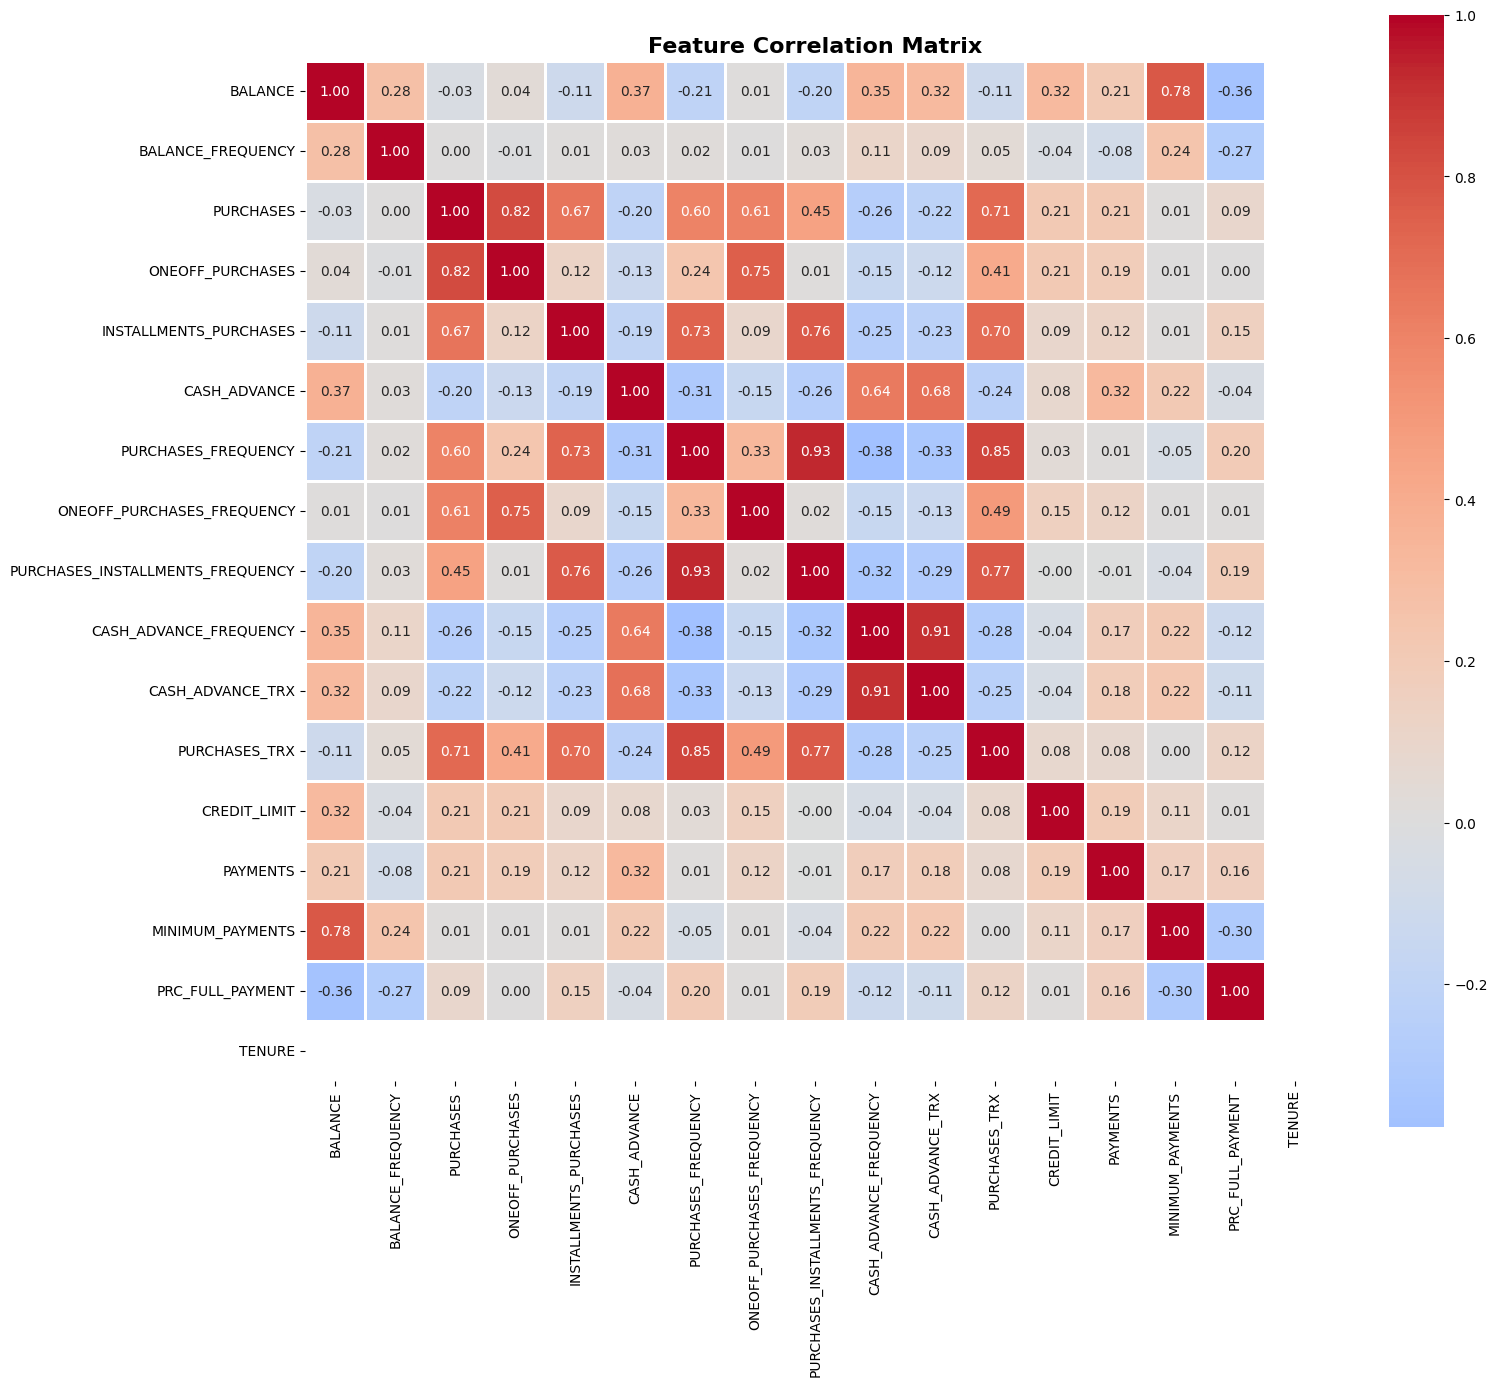

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'CUST_ID' in numeric_cols:
    numeric_cols.remove('CUST_ID')

plt.figure(figsize=(16, 14))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [10]:
print('OUTLIER DETECTION & REMOVAL')
print('='*60)
print('Method: IQR (Interquartile Range)')
print('Rule: Remove values < Q1-1.5×IQR or > Q3+1.5×IQR')
print('='*60)

features_for_outliers = [col for col in numeric_cols]
outliers_mask = pd.Series([False] * len(df))

for col in features_for_outliers:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    col_outliers = ((df[col] < lower) | (df[col] > upper))
    outliers_count = col_outliers.sum()
    
    if outliers_count > 0:
        print(f'{col:35s}: {outliers_count:5d} outliers ({outliers_count/len(df)*100:5.2f}%)')
        outliers_mask = outliers_mask | col_outliers

original_size = len(df)
df_clean = df[~outliers_mask].copy()
removed = original_size - len(df_clean)

print('\n' + '='*60)
print('OUTLIERS REMOVED')
print('='*60)
print(f'  Original dataset: {original_size:,} rows')
print(f'  Outliers removed: {removed:,} rows ({removed/original_size*100:.1f}%)')
print(f'  Clean dataset:    {len(df_clean):,} rows')
print('\n  Reason: Agglomerative clustering is sensitive to outliers (Lab)')
print('='*60)

df = df_clean.copy()

OUTLIER DETECTION & REMOVAL
Method: IQR (Interquartile Range)
Rule: Remove values < Q1-1.5×IQR or > Q3+1.5×IQR
BALANCE                            :   110 outliers ( 3.67%)
BALANCE_FREQUENCY                  :   366 outliers (12.22%)
PURCHASES                          :   103 outliers ( 3.44%)
ONEOFF_PURCHASES                   :   332 outliers (11.09%)
INSTALLMENTS_PURCHASES             :   160 outliers ( 5.34%)
CASH_ADVANCE                       :   254 outliers ( 8.48%)
ONEOFF_PURCHASES_FREQUENCY         :   201 outliers ( 6.71%)
CASH_ADVANCE_FREQUENCY             :    35 outliers ( 1.17%)
CASH_ADVANCE_TRX                   :   124 outliers ( 4.14%)
PURCHASES_TRX                      :    91 outliers ( 3.04%)
CREDIT_LIMIT                       :   201 outliers ( 6.71%)
PAYMENTS                           :   193 outliers ( 6.45%)
MINIMUM_PAYMENTS                   :   116 outliers ( 3.87%)
PRC_FULL_PAYMENT                   :   567 outliers (18.94%)

OUTLIERS REMOVED
  Original datase

C:\Users\fsoui\AppData\Local\Temp\ipykernel_17604\1453829955.py:26: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_clean = df[~outliers_mask].copy()


## **2. Data Preparation**

In [11]:
df_cluster = df.drop('CUST_ID', axis=1)

print('CUST_ID column dropped')
print(f'\nRemaining features: {df_cluster.shape[1]}')
print(f'Features: {list(df_cluster.columns)}')

CUST_ID column dropped

Remaining features: 17
Features: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


In [12]:
if df_cluster.isnull().sum().sum() > 0:
    print('Handling missing values...')
    print(f'Missing values before: {df_cluster.isnull().sum().sum()}')
    df_cluster = df_cluster.fillna(df_cluster.median())
    print(f'Missing values after: {df_cluster.isnull().sum().sum()}')
    print('Missing values filled with median')
else:
    print('No missing values to handle')

print(f'\nFinal dataset shape: {df_cluster.shape}')

Handling missing values...
Missing values before: 29
Missing values after: 0
Missing values filled with median

Final dataset shape: (1442, 17)


In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

print('FEATURES SCALED')
print('='*60)
print('Method: StandardScaler')
print('Formula: (x - mean) / std')
print('Result: All features now have mean≈0, std≈1')
print('='*60)
print(f'\nScaled data shape: {X_scaled.shape}')
print(f'  Samples (customers): {X_scaled.shape[0]:,}')
print(f'  Features:            {X_scaled.shape[1]}')
print('\n Data ready for Agglomerative Clustering!')

FEATURES SCALED
Method: StandardScaler
Formula: (x - mean) / std
Result: All features now have mean≈0, std≈1

Scaled data shape: (1442, 17)
  Samples (customers): 1,442
  Features:            17

 Data ready for Agglomerative Clustering!


## **3. Apply Agglomerative Clustering**

In [15]:
n_clusters = 3

print('APPLYING AGGLOMERATIVE CLUSTERING')
print('='*60)
print(f'Parameters:')
print(f'  n_clusters: {n_clusters}')
print(f'  linkage:    ward (minimize variance)')
print(f'  metric:     euclidean (straight-line distance)')
print('='*60)

agg = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage='ward',
    metric='euclidean'
)

labels = agg.fit_predict(X_scaled)

print('\n Clustering completed!')
print('\n' + '='*60)
print('CLUSTER DISTRIBUTION')
print('='*60)
for i in range(n_clusters):
    count = (labels == i).sum()
    pct = count / len(labels) * 100
    print(f'Cluster {i}: {count:5,} customers ({pct:5.1f}%)')
print('='*60)

APPLYING AGGLOMERATIVE CLUSTERING
Parameters:
  n_clusters: 3
  linkage:    ward (minimize variance)
  metric:     euclidean (straight-line distance)

 Clustering completed!

CLUSTER DISTRIBUTION
Cluster 0:   825 customers ( 57.2%)
Cluster 1:   257 customers ( 17.8%)
Cluster 2:   360 customers ( 25.0%)


## **4. Visualize the Clustering Results**

Creating dendrogram with sample of 100 customers...


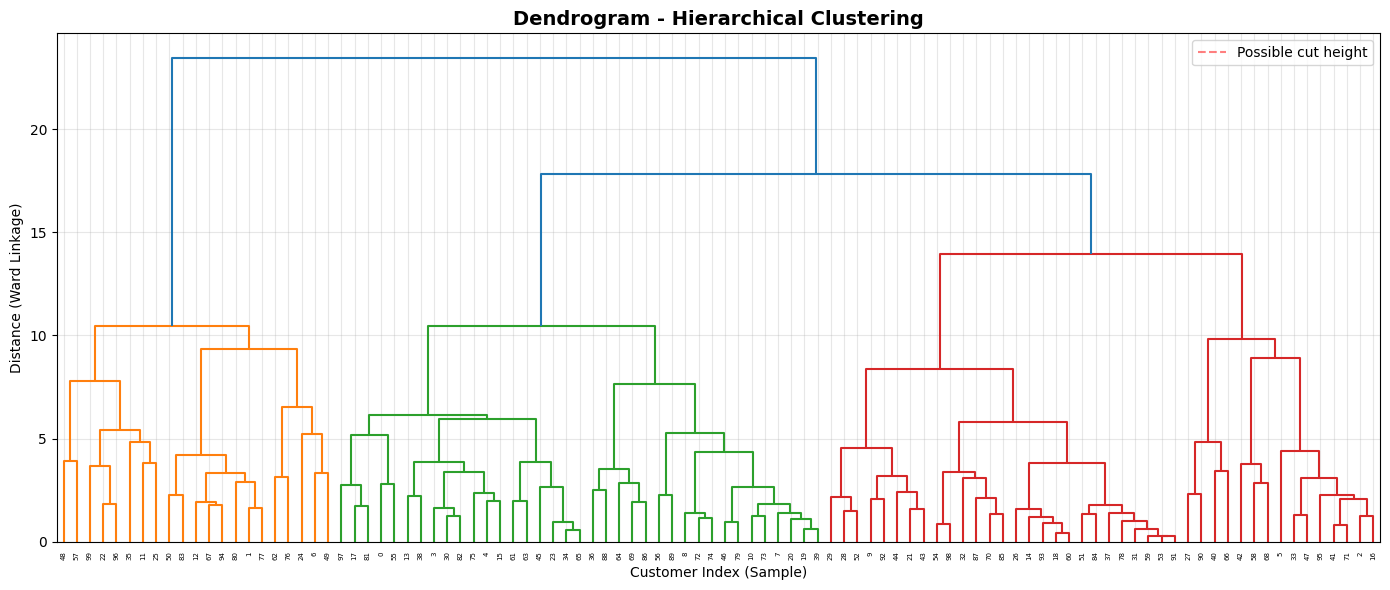

In [22]:
sample_size = min(100, len(X_scaled))
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), sample_size, replace=False)
X_sample = X_scaled[sample_idx]

print(f'Creating dendrogram with sample of {sample_size} customers...')

linkage_matrix = linkage(X_sample, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linkage_matrix)
plt.title('Dendrogram - Hierarchical Clustering', fontsize=14, fontweight='bold')
plt.xlabel('Customer Index (Sample)')
plt.ylabel('Distance (Ward Linkage)')
plt.grid(True, alpha=0.3)
plt.axhline(y=50, color='r', linestyle='--', alpha=0.5, label='Possible cut height')
plt.legend()
plt.tight_layout()
plt.show()

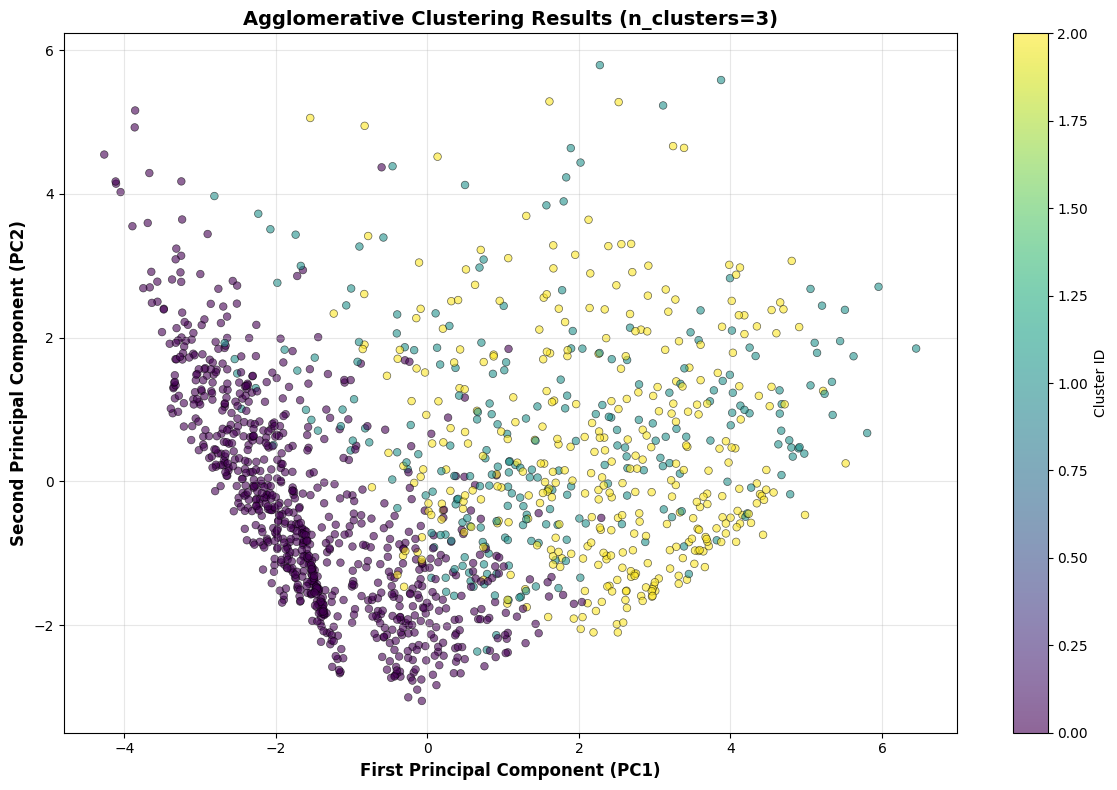

 PCA visualization displayed
  Variance explained by 2 components: 53.3%


In [18]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', 
                     s=30, alpha=0.6, edgecolors='black', linewidth=0.5)
plt.xlabel('First Principal Component (PC1)', fontsize=12, fontweight='bold')
plt.ylabel('Second Principal Component (PC2)', fontsize=12, fontweight='bold')
plt.title(f'Agglomerative Clustering Results (n_clusters={n_clusters})', 
         fontsize=14, fontweight='bold')
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

variance_explained = sum(pca.explained_variance_ratio_) * 100
print(f' PCA visualization displayed')
print(f'  Variance explained by 2 components: {variance_explained:.1f}%')

## **5. Evaluate the Clustering**

In [23]:
# Calculate Silhouette Score
score = silhouette_score(X_scaled, labels)

print('='*60)
print('CLUSTERING EVALUATION')
print('='*60)
print(f'Silhouette Score: {score:.4f}')
print()
if score > 0.7:
    quality = 'STRONG'
    emoji = '✓✓✓'
elif score > 0.5:
    quality = 'MODERATE'
    emoji = '✓✓'
elif score > 0.25:
    quality = 'WEAK'
    emoji = '⚠'
else:
    quality = 'POOR'
    emoji = '✗'

print(f'{emoji} Clustering Quality: {quality}')
print()
print('Score Ranges:')
print('  0.7 - 1.0: Strong clustering ✓✓✓')
print('  0.5 - 0.7: Moderate clustering ✓✓')
print('  0.25 - 0.5: Weak clustering ⚠')
print('  < 0.25: Poor clustering ✗')
print('='*60)

CLUSTERING EVALUATION
Silhouette Score: 0.2495

✗ Clustering Quality: POOR

Score Ranges:
  0.7 - 1.0: Strong clustering ✓✓✓
  0.5 - 0.7: Moderate clustering ✓✓
  0.25 - 0.5: Weak clustering ⚠
  < 0.25: Poor clustering ✗


In [20]:
df_with_clusters = df_cluster.copy()
df_with_clusters['Cluster'] = labels

print('CLUSTER CHARACTERISTICS')
print('='*80)
print('\nAverage Feature Values by Cluster:')
print('='*80)

cluster_means = df_with_clusters.groupby('Cluster').mean()
print(cluster_means.round(2))

print('\n' + '='*80)
print('TOP 3 FEATURES PER CLUSTER (Highest Values)')
print('='*80)

for i in range(n_clusters):
    print(f'\nCluster {i} ({(labels==i).sum()} customers):')
    print('-' * 40)
    cluster_data = cluster_means.loc[i]
    top_features = cluster_data.nlargest(3)
    for j, (feat, val) in enumerate(top_features.items(), 1):
        print(f'  {j}. {feat:30s}: {val:>10.2f}')

print('\n' + '='*80)

CLUSTER CHARACTERISTICS

Average Feature Values by Cluster:
         BALANCE  BALANCE_FREQUENCY  PURCHASES  ONEOFF_PURCHASES  \
Cluster                                                            
0        1285.63                1.0      45.26             28.37   
1        1161.88                1.0     484.50            342.40   
2        1016.56                1.0     365.33             33.74   

         INSTALLMENTS_PURCHASES  CASH_ADVANCE  PURCHASES_FREQUENCY  \
Cluster                                                              
0                         16.91        327.78                 0.07   
1                        142.10        195.62                 0.47   
2                        332.57        140.67                 0.74   

         ONEOFF_PURCHASES_FREQUENCY  PURCHASES_INSTALLMENTS_FREQUENCY  \
Cluster                                                                 
0                              0.03                              0.04   
1                            

## **6. Explain whether the clustering quality and justify your reasoning**

The clustering quality is poor. The silhouette score is 0.2495, which is below 0.25 and close to 0. This means the data points are near the boundary between clusters rather than clearly belonging to one cluster. The cluster means show all 3 clusters have similar top features (CREDIT_LIMIT, BALANCE, PAYMENTS) with close values, meaning the algorithm did not find strongly distinct customer groups. The PCA plot also shows heavy overlap between clusters. This is likely because the credit card dataset has many correlated features and does not have naturally well-separated groups for agglomerative clustering to find.
